# GloGEM vs GloGEMflow: Full Alpine domain

Total volume, relative volume and area timeseries for all Central European glaciers (RGI region 11),
comparing the Δh parameterisation against the SIA flowline model across three SSPs for both RGI6 and RGI7.

| Model | RGI version | Geometry | Style |
|-------|-------------|----------|-------|
| **GloGEMflow** | RGI7 | SIA flowline dynamics (Zekollari et al. 2019) | thick solid |
| **GloGEMflow** | RGI6 | SIA flowline dynamics (Zekollari et al. 2019) | thin solid |
| **GloGEM** | RGI7 | Δh parameterisation (Huss et al. 2010) | thick dashed |
| **GloGEM** | RGI6 | Δh parameterisation (Huss et al. 2010) | thin dashed |

GCM ensemble: all 13 available CMIP6 models (mean). SSPs: 1-2.6, 2-4.5, 5-8.5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

rcParams['font.family']       = 'sans-serif'
rcParams['font.sans-serif']   = ['Liberation Sans', 'Arial', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False
rcParams['axes.spines.top']    = False
rcParams['axes.spines.right']  = False

In [2]:
# ── Run directories ───────────────────────────────────────────────────────────
_BASE = '/scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development'
_SUB  = 'monthly/CentralEurope/files/files_original'

RUNS = {
    'dh_rgi7':   f'{_BASE}/alps_dhdt_rgi7',
    'dh_rgi6':   f'{_BASE}/alps_dhdt_rgi6',
    'flow_rgi7': f'{_BASE}/alps_flow_rgi7',
    'flow_rgi6': f'{_BASE}/alps_flow_rgi6',
}

# ── Batch configuration (all four runs use 24 batches) ───────────────────────
N_BATCHES    = 24
BATCH_PREFIX = 'alps_batch'

# ── GCMs — all 13 available CMIP6 models ────────────────────────────────────
ALL_GCMS = [
    'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM',
    'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4',
    'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM',
]

# ── SSPs and styling ──────────────────────────────────────────────────────────
SSPS       = ['ssp126', 'ssp245', 'ssp585']
SSP_LABELS = {'ssp126': 'SSP1-2.6', 'ssp245': 'SSP2-4.5', 'ssp585': 'SSP5-8.5'}
SSP_COLORS = {'ssp126': '#5492CD', 'ssp245': '#F6B334', 'ssp585': '#DC1C13'}

# ── Plot style per run: solid = flow, dashed = Δh; thick = RGI7, thin = RGI6 ─
RUN_STYLE = {
    'flow_rgi7': dict(ls='-',  lw=2.0, label='GloGEMflow  RGI7'),
    'flow_rgi6': dict(ls='-',  lw=1.0, label='GloGEMflow  RGI6'),
    'dh_rgi7':   dict(ls='--', lw=2.0, label='Δh param.   RGI7'),
    'dh_rgi6':   dict(ls='--', lw=1.0, label='Δh param.   RGI6'),
}

# ── Time axis (GloGEM output: 1940–2099, 160 years) ──────────────────────────
TRAN0   = 1940
N_YEARS = 160          # 1940–2099 inclusive
years   = np.arange(TRAN0, TRAN0 + N_YEARS)
I_2020  = 2020 - TRAN0   # index 80
I_LAST  = N_YEARS - 1    # index 159 = year 2099

# ── Inventory / survey date (nominal RGI outline date for Central Europe) ────
INVENTORY_YEAR = 2003

In [3]:
import re
from concurrent.futures import ThreadPoolExecutor

_num_re = re.compile(r'[+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?')

def _read_dat(path, row_max=None):
    """Read one .dat file; return column-summed array or None if missing/corrupt."""
    try:
        with open(path) as fh:
            header = fh.readline()
            ncols  = len(header.split()) - 1
            if ncols <= 0:
                return None
            total  = np.zeros(ncols)
            for line in fh:
                # Strip IDL overflow asterisks and -NaN (melted glaciers), then
                # extract all numeric tokens.
                nums = _num_re.findall(line.replace('*', '').replace('-NaN', '').replace('NaN', ''))
                if len(nums) < 2:
                    continue
                vals = np.zeros(ncols)
                for j, n in enumerate(nums[1:ncols + 1]):   # nums[0] = glacier ID
                    vals[j] = float(n)
                if row_max is not None and np.max(vals) > row_max:
                    continue   # skip blown-up glacier row
                total += vals
    except (FileNotFoundError, OSError, ValueError):
        return None
    return total


def _sum_gcm_batches(args):
    """Sum all 24 batch files for one (rundir, var, ssp, gcm) — run in thread."""
    rundir, var, ssp, gcm, row_max = args
    total, found = None, 0
    for i in range(1, N_BATCHES + 1):
        path = (f'{rundir}/{_SUB}/{gcm}/{ssp}/'
                f'centraleurope_{var}_r1_{BATCH_PREFIX}{i:02d}.dat')
        arr = _read_dat(path, row_max=row_max)
        if arr is not None:
            total = arr if total is None else total + arr
            found += 1
    return total, found, gcm


def load_mean(rundir, var, ssp, row_max=None):
    """GCM-ensemble mean across all batches; parallelises GCM reads via threads."""
    args = [(rundir, var, ssp, gcm, row_max) for gcm in ALL_GCMS]
    with ThreadPoolExecutor(max_workers=len(ALL_GCMS)) as ex:
        results = list(ex.map(_sum_gcm_batches, args))
    gcm_totals = []
    for total, found, gcm in results:
        if total is None:
            print(f'[missing all] {gcm}/{ssp}/{var}')
        elif found < N_BATCHES:
            print(f'[partial {found}/{N_BATCHES}] {gcm}/{ssp}/{var}')
        if total is not None:
            gcm_totals.append(total)
    return np.mean(gcm_totals, axis=0) if gcm_totals else None

In [4]:
def _load_one(args):
    tag, rundir, var, ssp = args
    row_max = 50. if var == 'Volume' else 500.
    return tag, var, ssp, load_mean(rundir, var, ssp, row_max=row_max)

tasks = [
    (tag, d, var, s)
    for tag, d in RUNS.items()
    for var in ('Volume', 'Area')
    for s in SSPS
]

vol  = {tag: {} for tag in RUNS}
area = {tag: {} for tag in RUNS}

with ThreadPoolExecutor(max_workers=6) as ex:
    for tag, var, ssp, result in ex.map(_load_one, tasks):
        (vol if var == 'Volume' else area)[tag][ssp] = result

# Sanity check
for tag in ['dh_rgi7', 'dh_rgi6', 'flow_rgi7', 'flow_rgi6']:
    for s in SSPS:
        v = vol[tag][s]
        if v is not None:
            print(f'{tag:<12}  {SSP_LABELS[s]}  '
                  f'vol_2020={v[I_2020]:.1f} km³   vol_2099={v[I_LAST]:.1f} km³')

dh_rgi7       SSP1-2.6  vol_2020=82.5 km³   vol_2099=24.0 km³
dh_rgi7       SSP2-4.5  vol_2020=82.5 km³   vol_2099=11.3 km³
dh_rgi7       SSP5-8.5  vol_2020=82.5 km³   vol_2099=2.8 km³
dh_rgi6       SSP1-2.6  vol_2020=100.2 km³   vol_2099=25.8 km³
dh_rgi6       SSP2-4.5  vol_2020=100.2 km³   vol_2099=11.7 km³
dh_rgi6       SSP5-8.5  vol_2020=100.2 km³   vol_2099=2.6 km³
flow_rgi7     SSP1-2.6  vol_2020=91.9 km³   vol_2099=65.3 km³
flow_rgi7     SSP2-4.5  vol_2020=91.9 km³   vol_2099=50.2 km³
flow_rgi7     SSP5-8.5  vol_2020=91.9 km³   vol_2099=38.7 km³
flow_rgi6     SSP1-2.6  vol_2020=102.7 km³   vol_2099=56.0 km³
flow_rgi6     SSP2-4.5  vol_2020=102.7 km³   vol_2099=40.0 km³
flow_rgi6     SSP5-8.5  vol_2020=102.7 km³   vol_2099=28.3 km³


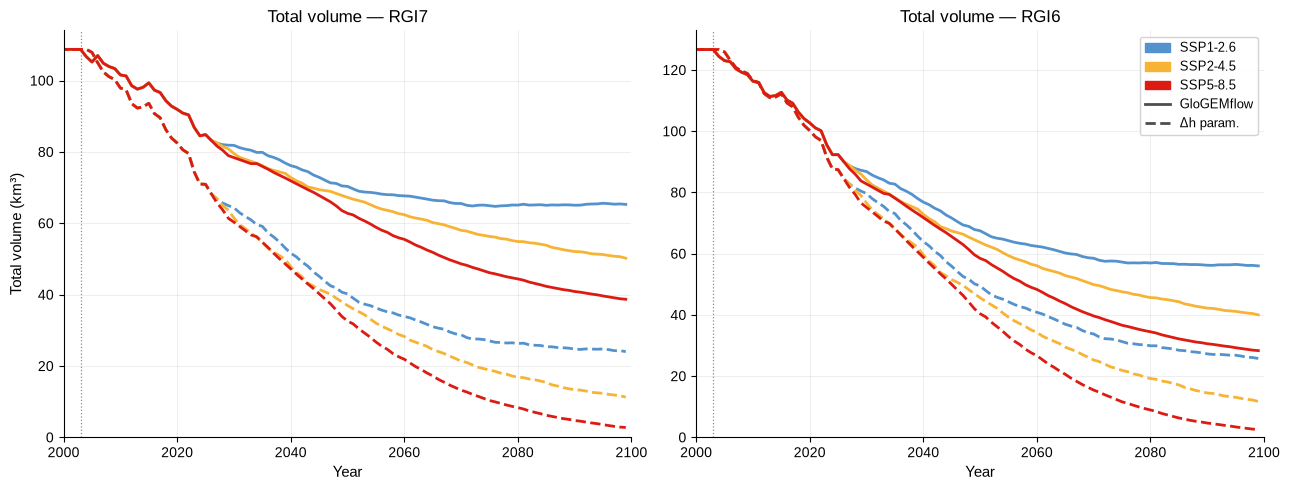

In [5]:
# ── Figure 1: Total volume — RGI7 (left) vs RGI6 (right) ────────────────────
PANELS = [
    ('RGI7', 'flow_rgi7', 'dh_rgi7'),
    ('RGI6', 'flow_rgi6', 'dh_rgi6'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (rgi_label, flow_tag, dh_tag) in zip(axes, PANELS):
    for ssp in SSPS:
        c = SSP_COLORS[ssp]
        for tag, ls in [(flow_tag, '-'), (dh_tag, '--')]:
            v = vol[tag][ssp]
            if v is not None:
                ax.plot(years, v, color=c, ls=ls, lw=2.0)
    ax.axvline(INVENTORY_YEAR, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(f'Total volume — {rgi_label}', fontsize=12)
    ax.grid(True, alpha=0.25, lw=0.6)

axes[0].set_ylabel('Total volume (km³)', fontsize=11)

legend_ssp = [Patch(color=SSP_COLORS[s], label=SSP_LABELS[s]) for s in SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=2.0, label='GloGEMflow'),
    Line2D([0], [0], color='0.3', ls='--', lw=2.0, label='Δh param.'),
]
axes[1].legend(handles=legend_ssp + legend_mdl, fontsize=9,
               loc='upper right', framealpha=0.85)

fig.tight_layout()
plt.show()

In [ ]:
# ── Figure 2: Relative volume (2020 = 100 %) — RGI7 (left) vs RGI6 (right) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (rgi_label, flow_tag, dh_tag) in zip(axes, PANELS):
    for ssp in SSPS:
        c = SSP_COLORS[ssp]
        for tag, ls in [(flow_tag, '-'), (dh_tag, '--')]:
            v = vol[tag][ssp]
            if v is not None and v[I_2020] > 0:
                ax.plot(years, v / v[I_2020] * 100, color=c, ls=ls, lw=2.0)
    ax.axhline(100, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.axvline(INVENTORY_YEAR, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(f'Relative volume (2020 = 100 %) — {rgi_label}', fontsize=12)
    ax.grid(True, alpha=0.25, lw=0.6)

axes[0].set_ylabel('Volume relative to 2020 (%)', fontsize=11)

legend_ssp = [Patch(color=SSP_COLORS[s], label=SSP_LABELS[s]) for s in SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=2.0, label='GloGEMflow'),
    Line2D([0], [0], color='0.3', ls='--', lw=2.0, label='Δh param.'),
]
axes[1].legend(handles=legend_ssp + legend_mdl, fontsize=9,
               loc='upper right', framealpha=0.85)

fig.tight_layout()
plt.show()

In [ ]:
# ── Figure 3: Total area — RGI7 (left) vs RGI6 (right) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (rgi_label, flow_tag, dh_tag) in zip(axes, PANELS):
    for ssp in SSPS:
        c = SSP_COLORS[ssp]
        for tag, ls in [(flow_tag, '-'), (dh_tag, '--')]:
            a = area[tag][ssp]
            if a is not None:
                ax.plot(years, a, color=c, ls=ls, lw=2.0)
    ax.axvline(INVENTORY_YEAR, color='0.55', lw=0.9, ls=':', zorder=0)
    ax.set_xlim(2000, 2100)
    ax.set_ylim(bottom=0)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(f'Total area — {rgi_label}', fontsize=12)
    ax.grid(True, alpha=0.25, lw=0.6)

axes[0].set_ylabel('Total area (km²)', fontsize=11)

legend_ssp = [Patch(color=SSP_COLORS[s], label=SSP_LABELS[s]) for s in SSPS]
legend_mdl = [
    Line2D([0], [0], color='0.3', ls='-',  lw=2.0, label='GloGEMflow'),
    Line2D([0], [0], color='0.3', ls='--', lw=2.0, label='Δh param.'),
]
axes[1].legend(handles=legend_ssp + legend_mdl, fontsize=9,
               loc='upper right', framealpha=0.85)

fig.tight_layout()
plt.show()

In [17]:
# ── Summary table ─────────────────────────────────────────────────────────────
TAGS    = ['dh_rgi7', 'dh_rgi6', 'flow_rgi7', 'flow_rgi6']
CLABELS = ['Δh-RGI7', 'Δh-RGI6', 'Flow-RGI7', 'Flow-RGI6']
W = 10

hdr = f"{'SSP':<12}" + "".join(f"  {c:>{W}}" for c in CLABELS)
sep = '-' * len(hdr)

def _v(tag, ssp, idx):
    v = vol[tag][ssp]
    return v[idx] if v is not None else float('nan')

print('-- Volume 2020 (km³) --')
print(hdr);  print(sep)
for ssp in SSPS:
    print(f'{SSP_LABELS[ssp]:<12}' + ''.join(f'  {_v(t,ssp,I_2020):>{W}.1f}' for t in TAGS))

print()
print('-- Volume 2099 (km³) --')
print(hdr);  print(sep)
for ssp in SSPS:
    print(f'{SSP_LABELS[ssp]:<12}' + ''.join(f'  {_v(t,ssp,I_LAST):>{W}.1f}' for t in TAGS))

print()
print('-- Volume loss 2020→2099 (%) --')
print(hdr);  print(sep)
for ssp in SSPS:
    row = f'{SSP_LABELS[ssp]:<12}'
    for tag in TAGS:
        v20, v99 = _v(tag, ssp, I_2020), _v(tag, ssp, I_LAST)
        loss = (1 - v99 / v20) * 100 if v20 > 0 else float('nan')
        row += f'  {loss:>{W}.1f}%'
    print(row)

print('\nΔh = Δh parameterisation.  Flow = GloGEMflow.  All volumes in km³.')

-- Volume 2020 (km³) --
SSP              Δh-RGI7     Δh-RGI6   Flow-RGI7   Flow-RGI6
------------------------------------------------------------
SSP1-2.6           115.3       131.1       124.4       138.7
SSP2-4.5           115.3       134.4       125.8       138.6
SSP5-8.5           115.2       132.7       126.6       138.7

-- Volume 2099 (km³) --
SSP              Δh-RGI7     Δh-RGI6   Flow-RGI7   Flow-RGI6
------------------------------------------------------------
SSP1-2.6            31.5        31.7        55.2        43.8
SSP2-4.5            14.4        14.8        36.4        21.5
SSP5-8.5             3.4         3.3        19.4         5.4

-- Volume loss 2020→2099 (%) --
SSP              Δh-RGI7     Δh-RGI6   Flow-RGI7   Flow-RGI6
------------------------------------------------------------
SSP1-2.6            72.7%        75.8%        55.6%        68.4%
SSP2-4.5            87.5%        89.0%        71.1%        84.5%
SSP5-8.5            97.0%        97.5%        84.7%     